# 04 Multi-Variable Cube: Adding Climate Data to NDVI

**Tutorial:** Building Geospatial Data Cubes for Earth Data Science  
**Focus:** Pine Ridge (Oglala Lakota Nation), South Dakota  
**Prerequisites:** Notebooks 00–03  

## What This Notebook Does
So far our cube holds one variable: NDVI. But the real power of a data cube
is holding multiple variables that share the same time axis, so you can
ask compound questions:

> *"Did vegetation decline in 2012 because it was unusually hot, unusually
> dry, or both at the same time?"*

To answer that, we need temperature and precipitation in the same cube as NDVI.

This notebook:
1. Fetches gridMET daily temperature and precipitation for Pine Ridge
2. Resamples both to monthly means (to match the NDVI time axis)
3. Merges everything into a single multi-variable xarray Dataset
4. Asks compound questions across variables
5. Builds a compound stress indicator from multiple variables

## Data Source: gridMET
gridMET is a daily 4km gridded climate dataset covering the continental US,
produced by the University of Idaho. It provides temperature, precipitation,
humidity, and fire weather variables back to 1979. We access it via OPeNDAP,
a protocol for requesting just the slice of data you need without downloading
entire files.

**Variables we will use:**
- `tmmx`: daily maximum temperature (in Kelvin, so convert to °F)
- `pr`  : daily precipitation (mm)

In [1]:
# Imports
import sys
from pathlib import Path

REPO_ROOT = Path().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import warnings
import datetime

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

from src.cube_utils import (
    fetch_ndvi_timeseries,
    fetch_gridmet_point,
    timeseries_to_dataarray,
    compute_growing_season_mean,
    compute_anomaly,
    CACHE_DIR,
)

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
%matplotlib inline

PINE_RIDGE_LAT =  43.35
PINE_RIDGE_LON = -102.09
GROWING_MONTHS = [5, 6, 7, 8, 9]
START_YEAR     = 2000
END_YEAR       = 2023

def despine(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

print("Setup complete.")

Setup complete.


## Load the NDVI Cube from Notebook 03

In [2]:
# Load the monthly NDVI cube saved at the end of notebook 03
monthly_path = CACHE_DIR/"pine_ridge_ndvi_monthly.nc"

if monthly_path.exists():
    ndvi_monthly_ds = xr.open_dataset(monthly_path)
    ndvi_monthly    = ndvi_monthly_ds["ndvi"]
    print(f"Monthly NDVI loaded: {len(ndvi_monthly)} months")
else:
    # Rebuild if notebook 03 hasn't been run
    print("Monthly cube not found, fetching and resampling NDVI...")
    ndvi_df      = fetch_ndvi_timeseries(
        PINE_RIDGE_LAT, PINE_RIDGE_LON,
        START_YEAR, END_YEAR, "pine_ridge"
    )
    ndvi_16day   = timeseries_to_dataarray(ndvi_df, name="ndvi")
    ndvi_monthly = ndvi_16day.resample(time="MS").mean()
    print(f"Resampled to {len(ndvi_monthly)} monthly observations")

print(f"Date range: {str(ndvi_monthly.time.values[0])[:10]} "
      f"to {str(ndvi_monthly.time.values[-1])[:10]}")

Monthly NDVI loaded: 287 months
Date range: 2000-02-01 to 2023-12-01


## Fetch gridMET Temperature and Precipitation
gridMET provides daily data. We fetch two variables and resample
to monthly means so they align with our NDVI time axis.

In [3]:
# Fetch daily maximum temperature
# gridMET tmmx is in Kelvin, so we convert to Fahrenheit
# First run: ~2 minutes. Subsequent runs: instant from cache.

tmax_df = fetch_gridmet_point(
    lat=PINE_RIDGE_LAT, lon=PINE_RIDGE_LON,
    variable="tmmx",
    start_year=START_YEAR, end_year=END_YEAR,
    site_name="pine_ridge",
)

# Convert Kelvin → Fahrenheit
tmax_df["tmmx"] = (tmax_df["tmmx"] - 273.15) * 9/5 + 32

print(f"Temperature data: {len(tmax_df):,} daily observations")
print(f"Range: {tmax_df['tmmx'].min():.1f}°F to {tmax_df['tmmx'].max():.1f}°F")
print(tmax_df.head(4).to_string(index=False))

  Cached 8766 daily observations → gridmet_tmmx_pine_ridge_2000_2023.csv
Temperature data: 8,766 daily observations
Range: -7.5°F to 109.5°F
      date  tmmx
2000-01-01 44.33
2000-01-02 44.51
2000-01-03 31.19
2000-01-04 32.81


In [4]:
# Fetch daily precipitation
precip_df = fetch_gridmet_point(
    lat=PINE_RIDGE_LAT, lon=PINE_RIDGE_LON,
    variable="pr",
    start_year=START_YEAR, end_year=END_YEAR,
    site_name="pine_ridge",
)

print(f"Precipitation data: {len(precip_df):,} daily observations")
print(f"Annual mean: {precip_df['pr'].sum() / (END_YEAR - START_YEAR + 1):.0f} mm/year")
print(precip_df.head(4).to_string(index=False))

  Cached 8766 daily observations → gridmet_pr_pine_ridge_2000_2023.csv
Precipitation data: 8,766 daily observations
Annual mean: 500 mm/year
      date  pr
2000-01-01 0.0
2000-01-02 3.6
2000-01-03 0.0
2000-01-04 0.3


## Resample to Monthly
NDVI is already monthly. Temperature and precipitation are daily.
We need to align all three on the same time axis before merging.

In [5]:
# Convert daily DataFrames to DataArrays
tmax_da_daily = timeseries_to_dataarray(
    tmax_df, date_col="date", value_col="tmmx",
    name="tmax_f",
    attrs={
        "long_name": "Daily maximum temperature",
        "units":     "degrees Fahrenheit",
        "source":    "gridMET via OPeNDAP",
    }
)

precip_da_daily = timeseries_to_dataarray(
    precip_df, date_col="date", value_col="pr",
    name="precip_mm",
    attrs={
        "long_name": "Daily precipitation",
        "units":     "mm",
        "source":    "gridMET via OPeNDAP",
    }
)

# Resample to monthly
# Temperature: monthly mean of daily maximum
# Precipitation: monthly total (sum, not mean)
tmax_monthly   = tmax_da_daily.resample(time="MS").mean()
precip_monthly = precip_da_daily.resample(time="MS").sum()

tmax_monthly.attrs["temporal_res"]   = "monthly mean of daily maximum"
precip_monthly.attrs["temporal_res"] = "monthly total precipitation"
precip_monthly.attrs["units"]        = "mm/month"

print(f"Temperature resampled: {len(tmax_monthly)} monthly values")
print(f"Precipitation resampled: {len(precip_monthly)} monthly values")
print(f"NDVI:                    {len(ndvi_monthly)} monthly values")

Temperature resampled: 288 monthly values
Precipitation resampled: 288 monthly values
NDVI:                    287 monthly values


## Build the Multi-Variable Cube
Now we merge all three variables into a single xarray Dataset.
The main requirement: they must share the same time coordinates.

In [6]:
# Find the common time range across all three variables
t_start = max(
    pd.Timestamp(ndvi_monthly.time.values[0]),
    pd.Timestamp(tmax_monthly.time.values[0]),
    pd.Timestamp(precip_monthly.time.values[0]),
)
t_end = min(
    pd.Timestamp(ndvi_monthly.time.values[-1]),
    pd.Timestamp(tmax_monthly.time.values[-1]),
    pd.Timestamp(precip_monthly.time.values[-1]),
)

print(f"Common time range: {t_start.date()} to {t_end.date()}")

# Slice each variable to the common range
ndvi_aligned   = ndvi_monthly.sel(time=slice(t_start, t_end))
tmax_aligned   = tmax_monthly.sel(time=slice(t_start, t_end))
precip_aligned = precip_monthly.sel(time=slice(t_start, t_end))

print(f"NDVI:   {len(ndvi_aligned)} months")
print(f"Tmax:   {len(tmax_aligned)} months")
print(f"Precip: {len(precip_aligned)} months")

Common time range: 2000-02-01 to 2023-12-01
NDVI:   287 months
Tmax:   287 months
Precip: 287 months


In [7]:
# Build the multi-variable Dataset
pine_ridge_cube = xr.Dataset(
    data_vars={
        "ndvi":      ndvi_aligned,
        "tmax_f":    tmax_aligned,
        "precip_mm": precip_aligned,
    },
    attrs={
        "title":        "Pine Ridge Multi-Variable Environmental Cube",
        "location":     "Pine Ridge Reservation, Oglala Lakota Nation",
        "centroid_lat": PINE_RIDGE_LAT,
        "centroid_lon": PINE_RIDGE_LON,
        "variables":    "ndvi (MODIS MOD13Q1), tmax_f (gridMET), precip_mm (gridMET)",
        "temporal_res": "monthly",
        "created":      datetime.datetime.now(datetime.timezone.utc).isoformat(),
        "tk_community": "Oglala Lakota Nation",
        "tk_usage":     "Non-commercial environmental research",
        "ieee_2890":    "https://standards.ieee.org/ieee/2890/10318/",
    }
)

print("Multi-variable cube:")
print(pine_ridge_cube)
print(f"\nVariables: {list(pine_ridge_cube.data_vars)}")
print(f"Dimensions: {dict(pine_ridge_cube.dims)}")

Multi-variable cube:
<xarray.Dataset> Size: 9kB
Dimensions:    (time: 287)
Coordinates:
  * time       (time) datetime64[ns] 2kB 2000-02-01 2000-03-01 ... 2023-12-01
Data variables:
    ndvi       (time) float64 2kB ...
    tmax_f     (time) float64 2kB 46.74 54.24 60.15 72.12 ... 60.32 53.92 44.91
    precip_mm  (time) float64 2kB 20.8 55.1 108.3 63.2 ... 54.8 95.5 4.1 20.9
Attributes:
    title:         Pine Ridge Multi-Variable Environmental Cube
    location:      Pine Ridge Reservation, Oglala Lakota Nation
    centroid_lat:  43.35
    centroid_lon:  -102.09
    variables:     ndvi (MODIS MOD13Q1), tmax_f (gridMET), precip_mm (gridMET)
    temporal_res:  monthly
    created:       2026-04-22T14:05:50.083977+00:00
    tk_community:  Oglala Lakota Nation
    tk_usage:      Non-commercial environmental research
    ieee_2890:     https://standards.ieee.org/ieee/2890/10318/

Variables: ['ndvi', 'tmax_f', 'precip_mm']
Dimensions: {'time': 287}


## Ask Compound Questions
With multiple variables in one cube, we can ask questions that
require looking at several factors simultaneously.

In [8]:
# Question 1: What were the hottest AND driest growing season months?
# These are the months most likely to cause stress.

# Select growing season months only
gs_mask = pine_ridge_cube.time.dt.month.isin(GROWING_MONTHS)
gs_cube = pine_ridge_cube.sel(time=gs_mask)

# Months that are both hot (top 25% tmax) AND dry (bottom 25% precip)
tmax_75  = float(gs_cube["tmax_f"].quantile(0.75))
precip_25 = float(gs_cube["precip_mm"].quantile(0.25))

hot_and_dry = gs_cube.where(
    (gs_cube["tmax_f"] > tmax_75) & (gs_cube["precip_mm"] < precip_25)
)

n_stress = int(hot_and_dry["ndvi"].count())
mean_ndvi_stress = float(hot_and_dry["ndvi"].mean())
mean_ndvi_normal = float(gs_cube["ndvi"].mean())

print("Compound heat and drought stress analysis:")
print(f"  Hot threshold (75th pct tmax):  > {tmax_75:.1f}°F")
print(f"  Dry threshold (25th pct precip): < {precip_25:.1f} mm/month")
print(f"\n  Growing season months meeting BOTH criteria: {n_stress}")
print(f"  Mean NDVI during stressed months: {mean_ndvi_stress:.4f}")
print(f"  Mean NDVI during all growing season months: {mean_ndvi_normal:.4f}")
print(f"  NDVI reduction under compound stress: {mean_ndvi_stress - mean_ndvi_normal:+.4f}")

Compound heat and drought stress analysis:
  Hot threshold (75th pct tmax):  > 87.4°F
  Dry threshold (25th pct precip): < 34.1 mm/month

  Growing season months meeting BOTH criteria: 13
  Mean NDVI during stressed months: 0.4351
  Mean NDVI during all growing season months: 0.5140
  NDVI reduction under compound stress: -0.0789


In [9]:
# Question 2: Which years had the worst compound growing season conditions?

# Compute annual growing season means for each variable
annual_ndvi   = compute_growing_season_mean(
    pine_ridge_cube["ndvi"], months=GROWING_MONTHS
)
annual_tmax   = compute_growing_season_mean(
    pine_ridge_cube["tmax_f"], months=GROWING_MONTHS
)
annual_precip = gs_cube["precip_mm"].groupby("time.year").sum()  

# Compute anomalies for each variable
ndvi_anom   = compute_anomaly(annual_ndvi)
# positive = hotter than average
tmax_anom   = compute_anomaly(annual_tmax)
# negative = drier than average
precip_anom = compute_anomaly(annual_precip)  

# Build a compound stress score:
# High stress = low NDVI + high temperature + low precipitation
# Normalize each anomaly to 0–1 range then combine
def norm_01(da):
    return (da - da.min()) / (da.max() - da.min())

stress_score = (
    norm_01(-ndvi_anom) * 0.4    # NDVI below average = stress
    + norm_01(tmax_anom) * 0.3   # Temperature above average = stress
    + norm_01(-precip_anom) * 0.3  # Precipitation below average = stress
)

stress_df = pd.DataFrame({
    "year":          annual_ndvi.year.values,
    "ndvi_mean":     annual_ndvi.values.round(4),
    "tmax_mean_f":   annual_tmax.values.round(1),
    "precip_total_mm": annual_precip.values.round(0),
    "stress_score":  stress_score.values.round(3),
})

print("Annual compound stress score (0 = lowest, 1 = highest):")
print(
    stress_df.sort_values("stress_score", ascending=False)
    .head(10)
    .to_string(index=False)
)
print("\nTop stress years should correspond to known drought years.")

Annual compound stress score (0 = lowest, 1 = highest):
 year  ndvi_mean  tmax_mean_f  precip_total_mm  stress_score
 2012     0.4294         87.6            178.0         0.914
 2002     0.3911         82.6            214.0         0.814
 2006     0.4296         82.7            222.0         0.747
 2004     0.3775         79.6            268.0         0.719
 2007     0.4804         84.0            231.0         0.693
 2000     0.4898         82.6            197.0         0.662
 2003     0.4695         81.3            202.0         0.656
 2021     0.4902         83.3            248.0         0.647
 2022     0.4940         83.7            282.0         0.631
 2001     0.5189         81.9            267.0         0.549

Top stress years should correspond to known drought years.


## Visualizations

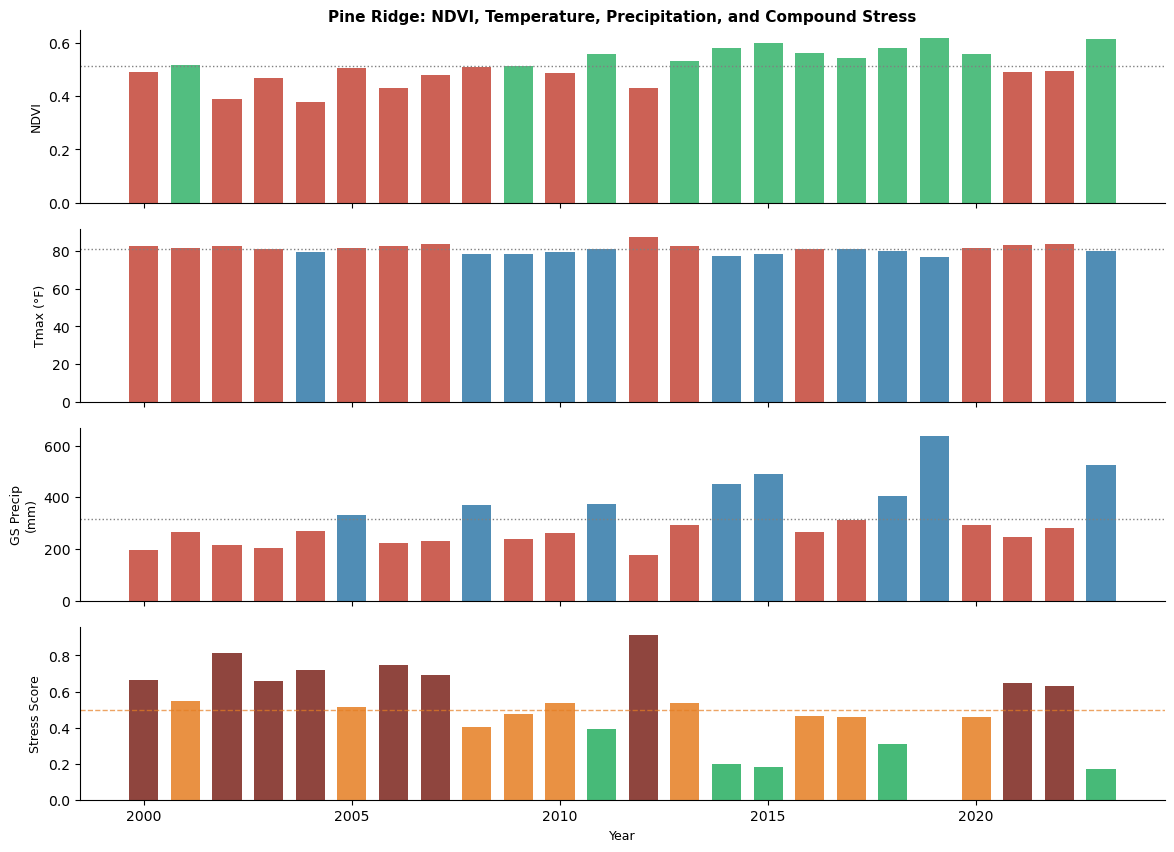

In [10]:
# Visualizations
years = stress_df["year"].values

fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(4, 1, hspace=0.15)

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1], sharex=ax1)
ax3 = fig.add_subplot(gs[2], sharex=ax1)
ax4 = fig.add_subplot(gs[3], sharex=ax1)

# NDVI
colors_ndvi = ["#C0392B" if v < stress_df["ndvi_mean"].mean() else "#27AE60"
               for v in stress_df["ndvi_mean"]]
ax1.bar(years, stress_df["ndvi_mean"], color=colors_ndvi, alpha=0.8, width=0.7)
ax1.axhline(stress_df["ndvi_mean"].mean(), color="gray", linewidth=1, linestyle=":")
ax1.set_ylabel("NDVI", fontsize=9)
ax1.set_title(
    "Pine Ridge: NDVI, Temperature, Precipitation, and Compound Stress",
    fontsize=11, fontweight="bold",
)
despine(ax1)

# Temperature
colors_temp = ["#C0392B" if v > stress_df["tmax_mean_f"].mean() else "#2471A3"
               for v in stress_df["tmax_mean_f"]]
ax2.bar(years, stress_df["tmax_mean_f"], color=colors_temp, alpha=0.8, width=0.7)
ax2.axhline(stress_df["tmax_mean_f"].mean(), color="gray", linewidth=1, linestyle=":")
ax2.set_ylabel("Tmax (°F)", fontsize=9)
despine(ax2)

# Precipitation
colors_precip = ["#C0392B" if v < stress_df["precip_total_mm"].mean() else "#2471A3"
                 for v in stress_df["precip_total_mm"]]
ax3.bar(years, stress_df["precip_total_mm"], color=colors_precip, alpha=0.8, width=0.7)
ax3.axhline(stress_df["precip_total_mm"].mean(), color="gray", linewidth=1, linestyle=":")
ax3.set_ylabel("GS Precip\n(mm)", fontsize=9)
despine(ax3)

# Compound stress score
colors_stress = ["#7B241C" if v > 0.6 else "#E67E22" if v > 0.4 else "#27AE60"
                 for v in stress_df["stress_score"]]
ax4.bar(years, stress_df["stress_score"], color=colors_stress, alpha=0.85, width=0.7)
ax4.axhline(0.5, color="#E67E22", linewidth=1, linestyle="--", alpha=0.7)
ax4.set_ylabel("Stress Score", fontsize=9)
ax4.set_xlabel("Year", fontsize=9)
despine(ax4)

plt.setp(ax1.get_xticklabels(), visible=False)
plt.setp(ax2.get_xticklabels(), visible=False)
plt.setp(ax3.get_xticklabels(), visible=False)

plt.tight_layout()
plt.show()

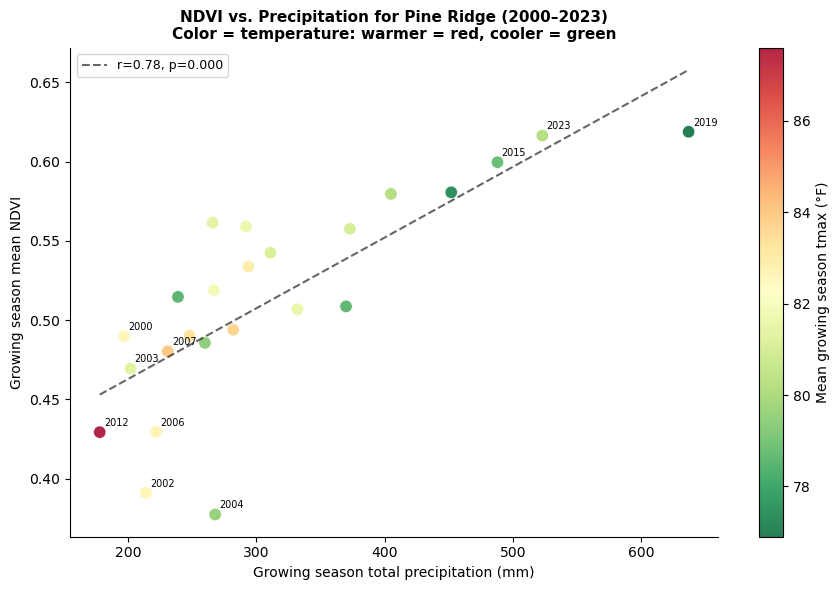


Correlation between precipitation and NDVI: r = 0.784 (p = 0.000)
Stronger correlation = precipitation is the primary driver of vegetation condition.


In [11]:
# Scatter plot: NDVI vs precipitation (colored by temperature)
fig, ax = plt.subplots(figsize=(9, 6))

sc = ax.scatter(
    stress_df["precip_total_mm"],
    stress_df["ndvi_mean"],
    c=stress_df["tmax_mean_f"],
    cmap="RdYlGn_r",
    s=80, alpha=0.85, edgecolors="white", linewidths=0.5,
)
plt.colorbar(sc, ax=ax, label="Mean growing season tmax (°F)")

# Label notable years
for _, row in stress_df.iterrows():
    if row["stress_score"] > 0.65 or row["stress_score"] < 0.2:
        ax.annotate(
            str(int(row["year"])),
            (row["precip_total_mm"], row["ndvi_mean"]),
            fontsize=7, ha="left", va="bottom",
            xytext=(3, 3), textcoords="offset points",
        )

# Trend line
slope, intercept, r, p, _ = stats.linregress(
    stress_df["precip_total_mm"], stress_df["ndvi_mean"]
)
x_range = np.linspace(
    stress_df["precip_total_mm"].min(),
    stress_df["precip_total_mm"].max(), 50
)
ax.plot(x_range, slope * x_range + intercept,
        color="black", linewidth=1.5, linestyle="--", alpha=0.6,
        label=f"r={r:.2f}, p={p:.3f}")

ax.set_xlabel("Growing season total precipitation (mm)", fontsize=10)
ax.set_ylabel("Growing season mean NDVI", fontsize=10)
ax.set_title(
    "NDVI vs. Precipitation for Pine Ridge (2000–2023)\n"
    "Color = temperature: warmer = red, cooler = green",
    fontsize=11, fontweight="bold",
)
ax.legend(fontsize=9)
despine(ax)
plt.tight_layout()
plt.show()

print(f"\nCorrelation between precipitation and NDVI: r = {r:.3f} (p = {p:.3f})")
print("Stronger correlation = precipitation is the primary driver of vegetation condition.")

## Save the Multi-Variable Cube

In [12]:
cube_path = CACHE_DIR/"pine_ridge_multi_variable_cube.nc"
pine_ridge_cube.to_netcdf(cube_path)
print(f"Multi-variable cube saved: {cube_path.name}")
print(f"File size: {cube_path.stat().st_size / 1024:.1f} KB")
print()
print("This cube contains:")
for var in pine_ridge_cube.data_vars:
    da = pine_ridge_cube[var]
    print(f"  {var}: {da.attrs.get('long_name', '')} ({da.attrs.get('units', '')})")

Multi-variable cube saved: pine_ridge_multi_variable_cube.nc
File size: 22.2 KB

This cube contains:
  ndvi: Normalized Difference Vegetation Index (dimensionless (0–1))
  tmax_f: Daily maximum temperature (degrees Fahrenheit)
  precip_mm: Daily precipitation (mm/month)


---
## Summary
You built a multi-variable data cube and used it to ask compound questions:

| What we did | xarray operation |
|---|---|
| Resample daily to monthly | `.resample(time="MS").mean()` |
| Align variables to common time | `.sel(time=slice(...))` |
| Merge into Dataset | `xr.Dataset({...})` |
| Filter on multiple conditions | `.where(cond1 & cond2)` |
| Compute growing season totals | `.groupby("time.year").sum()` |
| Normalize anomalies | `(da - da.min()) / (da.max() - da.min())` |

## Discussion Questions
1. The compound stress score weights NDVI at 40%, temperature at 30%,
   and precipitation at 30%. Should those weights be equal? What
   knowledge would you need to set them more accurately for Pine Ridge?

2. The scatter plot shows the correlation between precipitation and NDVI.
   Is the relationship linear? Are there years that don't fit the pattern?
   What might explain outliers?

3. gridMET is a modeled dataset, not directly measured. Its 4km pixels
   average conditions across a wide area. How might conditions at a
   specific pasture on Pine Ridge differ from the gridMET value for
   that location?

## Next Notebook
**05 Spatial Operations:** We add the spatial dimension by loading
raster data that covers the full Pine Ridge extent, clipping to the
Tribal boundary, and comparing conditions across different parts
of the reservation.